# anchored — Dataset & RAG Exploration

> A working notebook for the **anchored** project: explore the CUAD contract corpus, then
> probe the current naive dense-retrieval baseline with concrete **good** and **bad** cases.
>
> This is a build-in-public artifact — the charts and the failure walk-throughs are the point.

**Contents**
1. [The corpus](#1) — what CUAD is, in numbers and charts
2. [Chunks & spans](#2) — how the corpus is sliced for retrieval
3. [The RAG baseline](#3) — recall by category, score distributions
4. [✅ Good cases](#4) — queries that work, with the retrieved clause
5. [❌ Bad cases](#5) — failure modes, and *why* they fail
6. [Takeaways](#6) — what this points at for Phase 1

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Run from the repo root regardless of where the kernel started (nbconvert uses the
# notebook's own directory as cwd).
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

INK, OXBLOOD, SEAL, GOOD = "#1c1a17", "#7c2d2d", "#b8763c", "#4f8a4f"

DATA_DIR = Path("data")
CUAD_JSON = DATA_DIR / "raw" / "CUAD_v1" / "CUAD_v1.json"
print("cwd:", Path.cwd(), "| CUAD present:", CUAD_JSON.exists())

cwd: /app | CUAD present: True


<a id="1"></a>
## 1. The corpus

[CUAD v1](https://www.atticusprojectai.org/cuad) (Contract Understanding Atticus Dataset,
CC BY 4.0): 510 commercial contracts, expert-annotated across 41 clause categories. Each
contract is asked all 41 questions; a question is *answerable* if that clause is present.

In [2]:
with CUAD_JSON.open() as f:
    cuad = json.load(f)["data"]

rows = []
for entry in cuad:
    title = entry["title"]
    context = entry["paragraphs"][0]["context"]
    for qa in entry["paragraphs"][0]["qas"]:
        category = qa["id"].split("__", 1)[1] if "__" in qa["id"] else qa["id"]
        answers = qa.get("answers", [])
        rows.append({
            "contract": title,
            "category": category,
            "answerable": len(answers) > 0,
            "n_answers": len(answers),
            "contract_len": len(context),
            "answer_len": len(answers[0]["text"]) if answers else 0,
        })

df = pd.DataFrame(rows)
print(f"{df.contract.nunique()} contracts × {df.category.nunique()} categories "
      f"= {len(df):,} questions")
print(f"answerable: {df.answerable.sum():,}  ({df.answerable.mean():.1%})")
df.head()

510 contracts × 41 categories = 20,910 questions
answerable: 6,702  (32.1%)


,contract,category,answerable,n_answers,contract_len,answer_len
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,True,1,54290,21
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,True,5,54290,11
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,True,1,54290,27
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,True,2,54290,273
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,True,1,54290,273


### Clause prevalence — how often each category actually appears

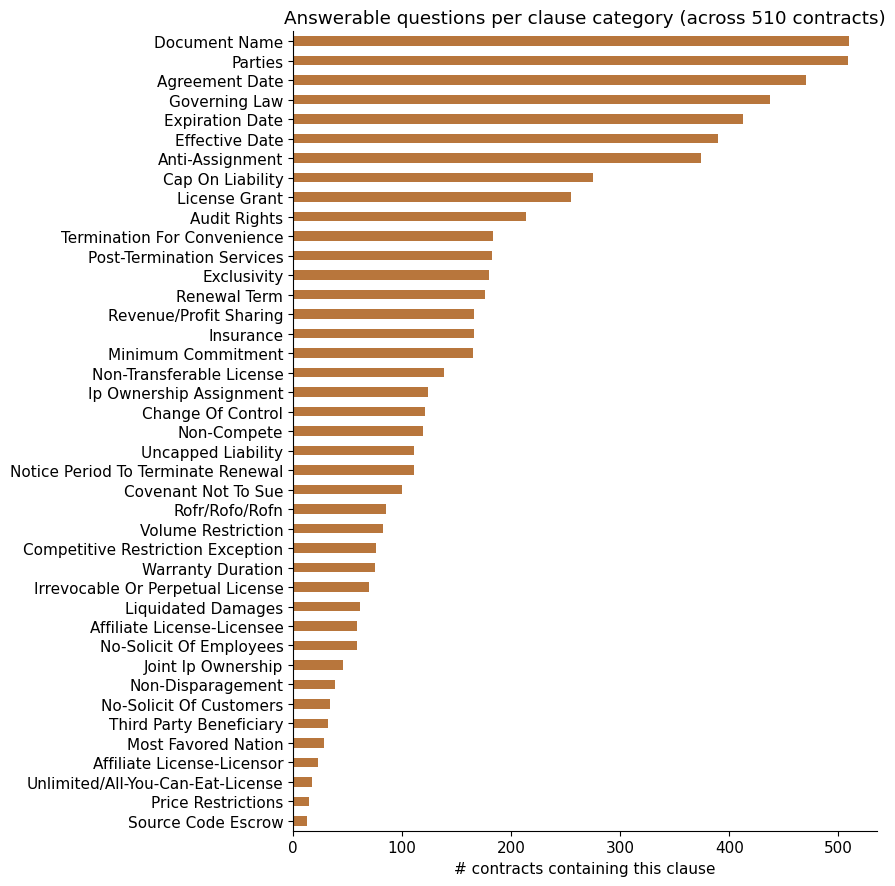

Most common: Document Name, Parties, Agreement Date
Rarest:      Unlimited/All-You-Can-Eat-License, Price Restrictions, Source Code Escrow


In [3]:
prevalence = (
    df[df.answerable].groupby("category").size()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 9))
prevalence.sort_values().plot.barh(ax=ax, color=SEAL)
ax.set_title("Answerable questions per clause category (across 510 contracts)")
ax.set_xlabel("# contracts containing this clause")
ax.set_ylabel("")
plt.tight_layout(); plt.show()

print("Most common:", ", ".join(prevalence.head(3).index))
print("Rarest:     ", ", ".join(prevalence.tail(3).index))

**Read:** the corpus is **imbalanced**. Some clauses (Parties, Governing Law, Document Name)
are in almost every contract; others (Most Favored Nation, Volume Restriction, the various
License sub-types) are rare. That long tail is exactly where retrieval will struggle.

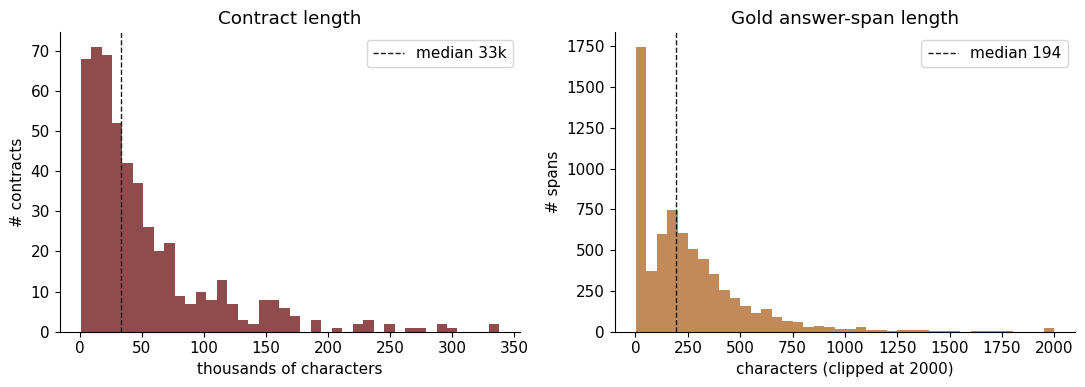

Contracts span 1k–338k chars; answer spans median 194 chars.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

contract_lens = df.groupby("contract").contract_len.first()
axes[0].hist(contract_lens / 1000, bins=40, color=OXBLOOD, alpha=0.85)
axes[0].set_title("Contract length")
axes[0].set_xlabel("thousands of characters"); axes[0].set_ylabel("# contracts")
axes[0].axvline(contract_lens.median() / 1000, color=INK, ls="--", lw=1,
                label=f"median {contract_lens.median()/1000:.0f}k")
axes[0].legend()

ans = df[df.answerable].answer_len
axes[1].hist(ans.clip(upper=2000), bins=40, color=SEAL, alpha=0.85)
axes[1].set_title("Gold answer-span length")
axes[1].set_xlabel("characters (clipped at 2000)"); axes[1].set_ylabel("# spans")
axes[1].axvline(ans.median(), color=INK, ls="--", lw=1, label=f"median {ans.median():.0f}")
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Contracts span {contract_lens.min()/1000:.0f}k–{contract_lens.max()/1000:.0f}k chars; "
      f"answer spans median {ans.median():.0f} chars.")

**Read:** contracts are long (tens of thousands of characters) but gold answer spans are
**short** (median ~a few hundred chars). We're looking for a needle in each contract — which
is why chunking and ranking matter so much.

<a id="2"></a>
## 2. Chunks & spans

The pipeline slices each contract into overlapping token windows (tiktoken `cl100k_base`,
512 tokens / 64 overlap), keeping exact char offsets so a retrieved chunk can be checked
against a gold span.

12,572 chunks across 510 contracts (avg 24.7 chunks/contract)


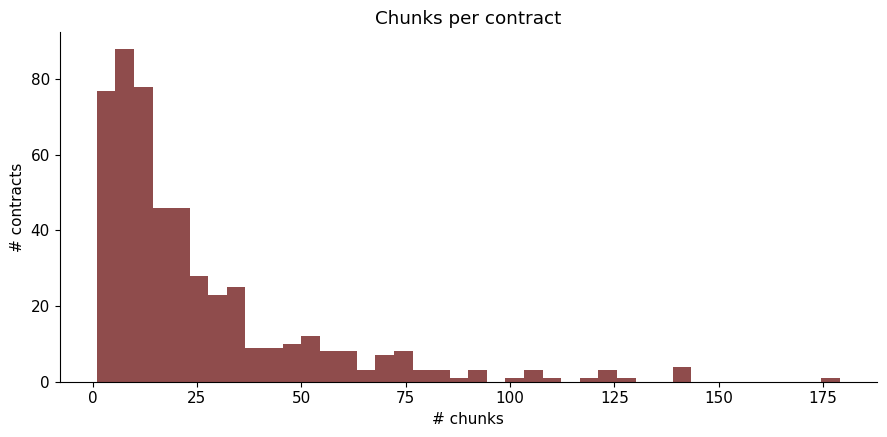

In [5]:
chunks_path = DATA_DIR / "processed" / "chunks.jsonl"
chunk_rows = []
if chunks_path.exists():
    with chunks_path.open() as f:
        for line in f:
            c = json.loads(line)
            chunk_rows.append({
                "contract_id": c["contract_id"],
                "chars": c["char_end"] - c["char_start"],
            })
    cdf = pd.DataFrame(chunk_rows)
    print(f"{len(cdf):,} chunks across {cdf.contract_id.nunique()} contracts "
          f"(avg {len(cdf)/cdf.contract_id.nunique():.1f} chunks/contract)")
    per = cdf.groupby("contract_id").size()
    fig, ax = plt.subplots()
    ax.hist(per, bins=40, color=OXBLOOD, alpha=0.85)
    ax.set_title("Chunks per contract"); ax.set_xlabel("# chunks"); ax.set_ylabel("# contracts")
    plt.tight_layout(); plt.show()
else:
    print("chunks.jsonl not found — run `make ingest` first.")

<a id="3"></a>
## 3. The RAG baseline

Now we run the actual retriever. We use the project's own eval harness over the live
Elasticsearch index (dense kNN, `bge-small-en-v1.5`), scoped to each target contract — the
realistic *find clause X in this document* task.

In [6]:
from evals.dataset import build_cases, read_dataset, write_dataset
from evals.retrieval_eval import evaluate

ds_path = Path("evals/cuad_retrieval.jsonl")
if not ds_path.exists():
    cases, stats = build_cases("data", per_category=5)
    write_dataset(cases, ds_path)
    print("built", stats)
cases = read_dataset(ds_path)
print(f"{len(cases)} eval cases across {len({c.category for c in cases})} categories")

report = evaluate(cases)
print(f"recall@5={report.recall_at_5}  recall@10={report.recall_at_10}  "
      f"precision@5={report.precision_at_5}")

onnxruntime cpuid_info warning: Unknown CPU vendor. cpuinfo_vendor value: 0


205 eval cases across 41 categories


recall@5=0.678  recall@10=0.8146  precision@5=0.1883


### Recall by clause category — where retrieval wins and loses

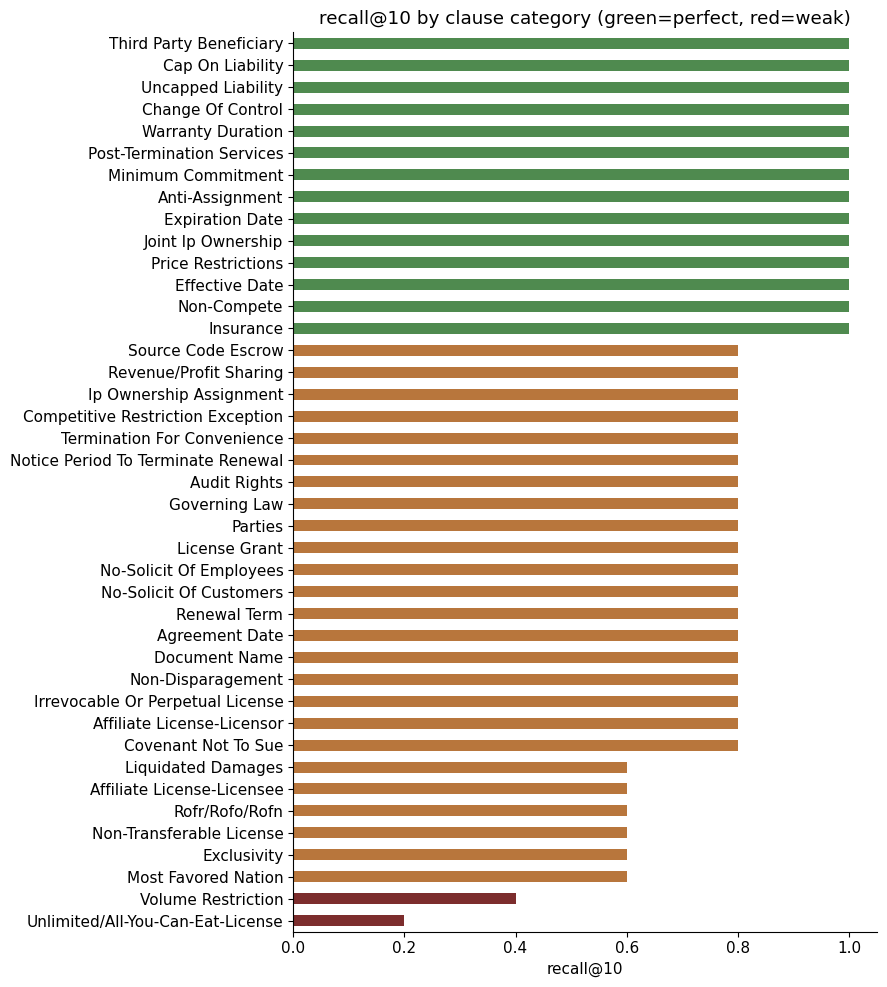

WEAKEST: Unlimited/All-You-Can-Eat-License, Volume Restriction, Most Favored Nation, Exclusivity, Non-Transferable License, Rofr/Rofo/Rofn
PERFECT (recall@10=1.0): 14 categories


In [7]:
by_cat = report.by_category()
cat_df = (
    pd.DataFrame(by_cat).T[["recall@5", "recall@10"]]
    .sort_values(["recall@10", "recall@5"])
)
fig, ax = plt.subplots(figsize=(9, 10))
colors = [GOOD if v == 1.0 else (SEAL if v >= 0.6 else OXBLOOD) for v in cat_df["recall@10"]]
cat_df["recall@10"].plot.barh(ax=ax, color=colors)
ax.set_title("recall@10 by clause category (green=perfect, red=weak)")
ax.set_xlabel("recall@10"); ax.set_ylabel(""); ax.set_xlim(0, 1.05)
plt.tight_layout(); plt.show()

worst = cat_df.head(6); best = cat_df[cat_df["recall@10"] == 1.0]
print("WEAKEST:", ", ".join(worst.index))
print(f"PERFECT (recall@10=1.0): {len(best)} categories")

### Score distributions — hits vs misses

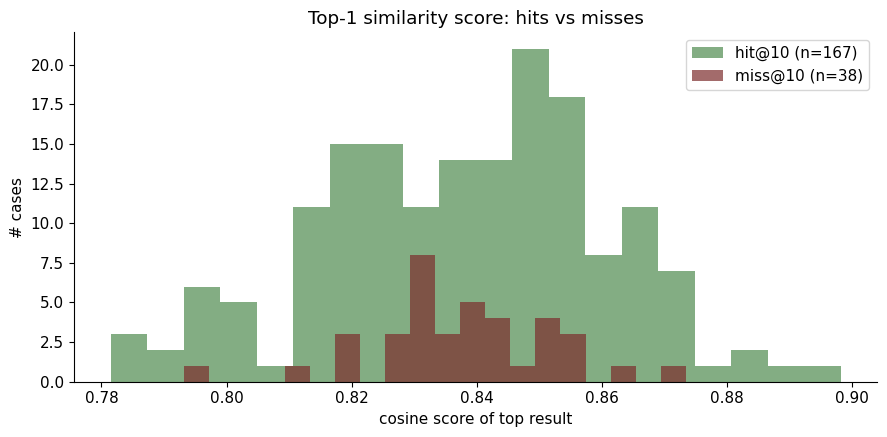

hits  top-score: mean 0.838
misses top-score: mean 0.837


In [8]:
hit_scores = [c.top_score for c in report.case_results if c.hit_at_10 and c.top_score]
miss_scores = [c.top_score for c in report.case_results if not c.hit_at_10 and c.top_score]

fig, ax = plt.subplots()
ax.hist(hit_scores, bins=20, alpha=0.7, color=GOOD, label=f"hit@10 (n={len(hit_scores)})")
ax.hist(miss_scores, bins=20, alpha=0.7, color=OXBLOOD, label=f"miss@10 (n={len(miss_scores)})")
ax.set_title("Top-1 similarity score: hits vs misses")
ax.set_xlabel("cosine score of top result"); ax.set_ylabel("# cases"); ax.legend()
plt.tight_layout(); plt.show()

print(f"hits  top-score: mean {pd.Series(hit_scores).mean():.3f}")
print(f"misses top-score: mean {pd.Series(miss_scores).mean():.3f}")

**Read:** misses don't have dramatically lower top scores — the model is often *confident
and wrong*. A raw score threshold alone won't separate them; we need lexical signal
(hybrid) and reranking, not just a cutoff.

<a id="4"></a>
## 4. ✅ Good cases

Let's look at retrieval *working*: pick cases that hit @5 and show the retrieved span next
to the gold clause. Helper below pretty-prints a case.

In [9]:
from anchored.retrieve.search import dense_search

def show_case(case, k=5, max_chars=320):
    gold = case.gold_spans
    res = dense_search(case.question, k=k, contract_id=case.contract_id, trace=False)
    detail = case.question.split("Details:", 1)[-1].strip()
    print(f"CATEGORY : {case.category}")
    print(f"QUESTION : {detail[:130]}")
    print(f"CONTRACT : {case.contract_id[:70]}")
    print(f"GOLD SPAN: chars {gold[0][0]}–{gold[0][1]}")
    print("-" * 80)
    for i, r in enumerate(res, 1):
        rel = any(r.chunk.overlaps(s, e) for s, e in gold)
        mark = "✅" if rel else "  "
        snip = " ".join(r.chunk.text.split())[:max_chars]
        print(f"{mark} #{i} score={r.score:.3f} [{r.chunk.char_start}-{r.chunk.char_end}]")
        print(f"     {snip}…")
    print("=" * 80)

by_cat_cases = {}
for c in cases:
    by_cat_cases.setdefault(c.category, []).append(c)

# Pick strong categories with a clean hit.
good_targets = ["Cap On Liability", "Change Of Control", "Governing Law"]
for cat in good_targets:
    for c in by_cat_cases.get(cat, []):
        r = dense_search(c.question, k=5, contract_id=c.contract_id, trace=False)
        if any(any(x.chunk.overlaps(s, e) for s, e in c.gold_spans) for x in r):
            show_case(c); break

CATEGORY : Cap On Liability
QUESTION : Does the contract include a cap on liability upon the breach of a party’s obligation? This includes time limitation for the counte
CONTRACT : WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMEN
GOLD SPAN: chars 34289–34657
--------------------------------------------------------------------------------
   #1 score=0.828 [20265-22625]
     unless earlier terminated as set out in this Agreement, shall continue for the Term. 5.2 Termination for breach. A party may suspend performance and/or terminate this Agreement, with immediate effect, if the other party: (a) is in material breach of this Agreement where the breach is incapable of remedy; or (b) is in m…
   #2 score=0.820 [41435-43148]
     relation to any dispute (contractual or non-contractual) concerning this Agreement save that either party may apply to any court for an injunction or other relief to protect its Intellectual Property Rights. If this Agreement is translated in

CATEGORY : Governing Law
QUESTION : Which state/country's law governs the interpretation of the contract?
CONTRACT : WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMEN
GOLD SPAN: chars 41315–41644
--------------------------------------------------------------------------------
✅ #1 score=0.820 [39265-41769]
     3 Assignment. [ * ] may [ * ]any of its rights or obligations under this Agreement without the prior written consent of [ * ]. For the avoidance of doubt, a Change of Control shall be deemed an assignment hereunder unless [ * ] does not exercise its [ * ]. 11.4 Force Majeure. Neither party shall be liable for failure t…
✅ #2 score=0.812 [41435-43148]
     relation to any dispute (contractual or non-contractual) concerning this Agreement save that either party may apply to any court for an injunction or other relief to protect its Intellectual Property Rights. If this Agreement is translated into any other language, if there is conflict the English text will 

**Read:** for short, lexically distinctive clauses the right span lands at rank 1 with a
high score and clearly overlaps the gold annotation. This is dense retrieval at its best.

<a id="5"></a>
## 5. ❌ Bad cases — the failure modes

Now the interesting part. Two flavors of failure:

1. **Weak categories** — defined-term / diffuse clauses the embedder smooths away.
2. **Out-of-distribution queries** — questions CUAD has no answer to, where the system
   returns a confident-but-irrelevant span (no relevance gating).

In [10]:
# 5a. Weak categories — show a miss.
bad_targets = ["Unlimited/All-You-Can-Eat-License", "Most Favored Nation", "Volume Restriction"]
for cat in bad_targets:
    for c in by_cat_cases.get(cat, []):
        r = dense_search(c.question, k=10, contract_id=c.contract_id, trace=False)
        if not any(any(x.chunk.overlaps(s, e) for s, e in c.gold_spans) for x in r[:5]):
            show_case(c, k=5); break

CATEGORY : Unlimited/All-You-Can-Eat-License
QUESTION : Is there a clause granting one party an “enterprise,” “all you can eat” or unlimited usage license?
CONTRACT : CORIOINC_07_20_2000-EX-10.5-LICENSE AND HOSTING AGREEMENT
GOLD SPAN: chars 6848–7140
--------------------------------------------------------------------------------
   #1 score=0.839 [45141-47930]
     to do so by a Corporate Officer of Commerce One. Commerce One covenants that during the term of this Agreement, it will continue to require all Commerce One employees, agents, contractors or consultants to sign an Employee NDA/Invention Agreement and that Commerce One will furnish to Corio copies of such signed agreeme…
   #2 score=0.839 [50025-52678]
     (e.g., DHL, Federal Express, etc.); or (d) five (5) days after posting when sent by certified United States mail. Notice shall be sent to the parties at the addresses set forth on the first page of this Agreement or at such other address as shall be specified by either p

CATEGORY : Most Favored Nation
QUESTION : Is there a clause that if a third party gets better terms on the licensing or sale of technology/goods/services described in the c
CONTRACT : ChinaRealEstateInformationCorp_20090929_F-1_EX-10.32_4771615_EX-10.32_
GOLD SPAN: chars 12438–13356
--------------------------------------------------------------------------------
   #1 score=0.849 [25334-27765]
     , validly existing and in good standing under applicable Law; (b) the execution, delivery and performance of this Agreement and the consummation of the transactions contemplated hereby are within its corporate powers; (c) it has taken necessary steps to obtain authority and all necessary consents and approvals of any o…
   #2 score=0.839 [40228-42641]
     . 13 Source: CHINA REAL ESTATE INFORMATION CORP, F-1, 9/29/2009 10.10. No Third Party Beneficiaries. Except for the provisions of Article VII relating to indemnified parties, this Agreement shall be binding upon and inure solely to the ben

**Read:** for these clauses the top results are *plausible-looking* contract prose at decent
scores, but none overlap the gold span — the relevant clause either wasn't chunked well or
ranks below the cutoff. No amount of staring at the score tells you it's wrong.

In [11]:
# 5b. Out-of-distribution query — the "Connecticut" case from the demo.
ood = "I want discussions for Connecticut"
res = dense_search(ood, k=5, trace=False)  # NOT scoped — true open query
print(f"OOD QUERY: {ood!r}\n" + "-" * 80)
for i, r in enumerate(res, 1):
    snip = " ".join(r.chunk.text.split())[:200]
    print(f"  #{i} score={r.score:.3f}  {r.chunk.contract_id[:45]}")
    print(f"     {snip}…")
print("-" * 80)
print(f"top score {res[0].score:.3f} — high-looking, but the snippet is a table of "
      "store addresses. There is no 'discussions for Connecticut' clause in CUAD; the "
      "system has no way to say 'no confident match'.")

OOD QUERY: 'I want discussions for Connecticut'
--------------------------------------------------------------------------------
  #1 score=0.817  BONTONSTORESINC_04_20_2018-EX-99.3-AGENCY AGR
     9 3 1 4,692 357 Rochester 1,018 1 - 66 131 44 27 53 709 106 34 3 1 2,192 401 Ames 254 84 211 24 102 34 8 50 167 62 10 3 - 1,007 402 Mason City 708 196 23 31 144 31 19 70 266 64 6 3 - 1,560 403 Fort Do…
  #2 score=0.815  BONTONSTORESINC_04_20_2018-EX-99.3-AGENCY AGR
     064 520 129 330 56 45 77 689 263 18 3 45 3,356 421 Davenport 669 263 292 35 152 121 17 45 270 77 7 4 7 1,960 422 Moline 1,188 56 264 92 199 174 23 52 315 82 8 3 2 2,457 423 Southridge 539 - - 30 148 1…
  #3 score=0.815  BONTONSTORESINC_04_20_2018-EX-99.3-AGENCY AGR
     48 16 44 397 94 13 4 5 3,973 62 Eastern Hills 1,320 54 - 53 336 269 26 38 319 99 10 4 - 2,528 63 Sheridan 715 104 78 47 197 235 38 43 300 85 7 4 - 1,851 64 Southgate 1,066 223 242 40 166 190 19 41 249…
  #4 score=0.812  BONTONSTORESINC_04_20_2018-EX-99.3-AGENC

**Read:** the OOD query returns a ~0.81 score — not obviously low — yet the content is
irrelevant (a data table). This is the canonical *confidently wrong* failure. A relevance
threshold / CRAG-style classifier is needed to abstain.

<a id="6"></a>
## 6. Takeaways → Phase 1

| Observation (from this notebook) | Phase-1 fix |
|---|---|
| Weak on defined-term / rare clauses (License sub-types, MFN, Volume Restriction) | **Hybrid (BM25 + dense)** to recover exact-term signal |
| Misses often have high-ish scores; relevant chunk just outside top-k | **Reranking** over a larger candidate set |
| Long contracts, short gold spans; diffuse clauses chunked badly | **Contextual / late chunking** |
| OOD queries return confident-but-wrong spans | **Relevance threshold / CRAG** to abstain |

Each is a *break → measure → fix → write* loop, with this baseline as the starting line.
The numbers in this notebook are what we'll move.